In [ ]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


In [3]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print('ndim:', T.ndim, 'shape:', T.shape)

# 2. T + T
print('T + T:\n', T + T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
print('Transpose shape:', T.T.shape)
print('Reshaped to (2, 6):\n', T.reshape(2, 6))


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
ndim: 2 shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose shape: (4, 3)
Reshaped to (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

In [4]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print('Dimensions:', T.ndim)
print('Shape:', T.shape)

# 2. T + T
print('T + T:\n', T + T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
print('Transpose shape:', T.T.shape)
print('Reshaped to (2, 6):\n', T.reshape(2, 6))


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Dimensions: 2
Shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose shape: (4, 3)
Reshaped to (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))



In [ ]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))


In [ ]:
import numpy as np

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    l1_u = np.abs(u).sum()
    l2_u = np.linalg.norm(u)

    # 2. Cosine similarity of u and v
    dot_product = np.dot(u, v)
    l2_v = np.linalg.norm(v)
    cos_sim = dot_product / (l2_u * l2_v)

    print(f"Pair {i}: L1 Norm={l1_u}, L2 Norm={l2_u:.2f}, Cosine Similarity={cos_sim:.3f}")

# 3. Most similar pair = Pair 1 (Highest cosine similarity score)


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))


In [5]:
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
M_inv = np.linalg.inv(M)
M_trace = np.trace(M)
print("Inverse of M:\n", M_inv)
print("Trace of M:", M_trace)

# 2. M @ inv(M) == I ?
# Note: Use np.allclose due to tiny floating-point rounding errors
I_check = M @ M_inv
is_identity = np.allclose(I_check, np.eye(2))
print("\nDoes M @ inv(M) equal the Identity matrix?:", is_identity)

# 3. Is M symmetric? Is P orthogonal?
# Symmetric: Matrix equals its transpose (M == M.T)
is_symmetric = np.allclose(M, M.T)

# Orthogonal: Transpose times itself equals identity (P.T @ P == I)
is_orthogonal = np.allclose(P.T @ P, np.eye(2))

print("Is M symmetric?:", is_symmetric)
print("Is P orthogonal?:", is_orthogonal)



Inverse of M:
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M: 7.0

Does M @ inv(M) equal the Identity matrix?: True
Is M symmetric?: True
Is P orthogonal?: True


In [9]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)


Rotated corners:
 [[ 0.         0.8660254  0.3660254 -0.5      ]
 [ 0.         0.5        1.3660254  0.8660254]]


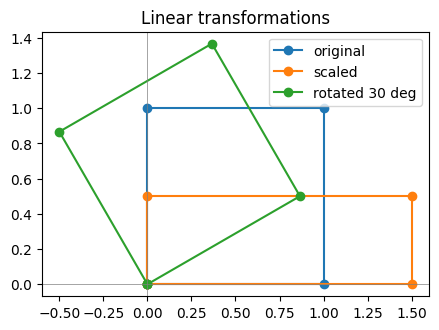

In [10]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

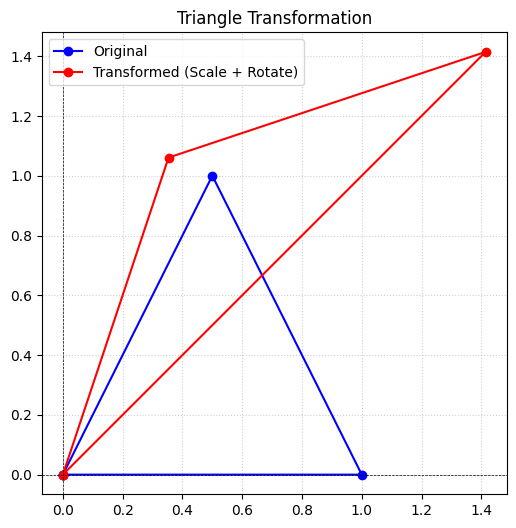

In [6]:
import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle (x in row 0, y in row 1)

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2.0, 0.0],
              [0.0, 0.5]])

# 2. Rotation matrix (45 degrees)
theta = np.radians(45)
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, -s],
              [s,  c]])

# 3. Apply both and plot original vs transformed
# Combined transformation matrix: Scale first, then Rotate
T = R @ S
tri_transformed = T @ tri

# Plotting setup (closing the loops for the triangles by repeating the first point)
tri_closed = np.hstack([tri, tri[:, [0]]])
tri_trans_closed = np.hstack([tri_transformed, tri_transformed[:, [0]]])

plt.figure(figsize=(6, 6))
plt.plot(tri_closed[0], tri_closed[1], 'b-o', label='Original')
plt.plot(tri_trans_closed[0], tri_trans_closed[1], 'r-o', label='Transformed (Scale + Rotate)')

# Aesthetics
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')
plt.legend()
plt.title('Triangle Transformation')
plt.show()


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

In [ ]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))


In [11]:
import numpy as np

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

# Solve the system
x = np.linalg.solve(A, b)

# Verification step (A @ x should equal b)
verification = A @ x
print("Does A @ x equal b?:", np.allclose(verification, b))
print("Resulting b vector:", verification)


Does A @ x equal b?: True
Resulting b vector: [  8. -11.  -3.]


In [ ]:

# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

In [ ]:
# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low

In [12]:
import numpy as np

# System arrays
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

# Semantic vectors
cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x = np.linalg.solve(A2, b2)
print("Solution x:", x)

# 2. Rank of A2
rank_A2 = np.linalg.matrix_rank(A2)
print("Rank of A2:", rank_A2)

# 3. cosine(cat, dog) and cosine(cat, car)
# Define a beginner-friendly function for cosine similarity
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

sim_cat_dog = cosine_similarity(cat, dog)
sim_cat_car = cosine_similarity(cat, car)

print(f"\nCosine similarity (cat, dog): {sim_cat_dog:.4f}")
print(f"Cosine similarity (cat, car): {sim_cat_car:.4f}")

# Determine which is more similar
if sim_cat_dog > sim_cat_car:
    print("Conclusion: 'cat' and 'dog' are more similar.")
else:
    print("Conclusion: 'cat' and 'car' are more similar.")



Solution x: [1. 2.]
Rank of A2: 2

Cosine similarity (cat, dog): 0.9946
Cosine similarity (cat, car): 0.2926
Conclusion: 'cat' and 'dog' are more similar.
